In [43]:
!pip install -q imbalanced-learn

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

from imblearn.over_sampling import SMOTE

In [45]:
X, y = make_classification(
    n_samples=10000,
    n_features=30,
    n_informative=20,
    n_redundant=5,
    n_classes=2,
    weights=[0.995, 0.005],
    random_state=42
)

df = pd.DataFrame(
    X,
    columns=[f'V{i}' for i in range(1,31)]
)

df['Class'] = y

print(df.shape)
df.head()

(10000, 31)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,V29,V30,Class
0,-4.111941,-0.472785,1.495009,3.401209,0.026572,2.093737,2.649069,1.726893,0.954298,-2.066497,...,0.969413,-0.636273,-13.376411,-1.107496,0.820539,0.651459,-0.109738,-1.374105,-0.470554,0
1,2.850813,-0.652570,-11.008422,-0.299120,3.801968,-3.515587,0.122762,2.095489,0.145276,2.906638,...,-4.338079,-0.788495,9.921859,-1.050834,-1.701214,-0.752823,2.583729,2.599217,2.614207,0
2,4.265028,1.414568,-1.812577,-2.316262,-2.625694,-0.124147,-3.483063,-2.563455,-0.030792,1.218929,...,2.559456,0.417948,6.202686,-2.262555,0.435347,0.907583,-1.334304,0.387922,-2.742920,0
3,5.316339,0.295956,28.947593,-0.040459,-6.684577,0.152203,1.777875,1.182769,0.301609,-3.176431,...,6.298994,6.432768,-7.966478,0.582654,0.316055,0.412278,-8.934865,-4.762778,-6.366670,0
4,7.438659,-1.313327,7.673740,2.256872,-3.856906,-3.004590,2.569723,-1.937835,0.104488,2.716901,...,4.188761,1.244554,-9.074826,5.353555,0.355623,-0.196183,-6.121174,4.535890,-0.528179,0


Class
0    9909
1      91
Name: count, dtype: int64


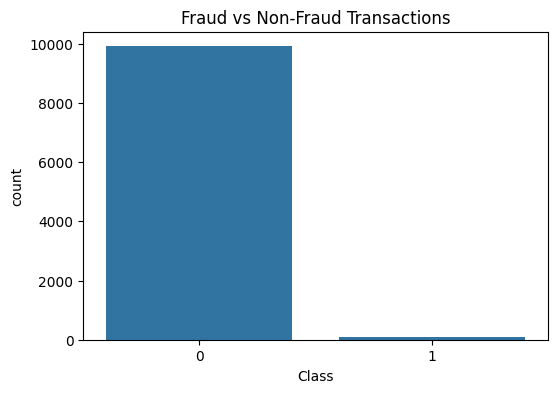

In [46]:
print(df['Class'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title('Fraud vs Non-Fraud Transactions')
plt.show()

In [47]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [48]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (8000, 30)
Test: (2000, 30)


In [49]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nClass distribution:")
print(pd.Series(y_train).value_counts())

X_train shape: (8000, 30)
y_train shape: (8000,)

Class distribution:
Class
0    7927
1      73
Name: count, dtype: int64


In [50]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE")
print(y_train.value_counts())

print("\nAfter SMOTE")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE
Class
0    7927
1      73
Name: count, dtype: int64

After SMOTE
Class
0    7927
1    7927
Name: count, dtype: int64


In [51]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_smote, y_train_smote)

lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:,1]

print("LOGISTIC REGRESSION")

print("Precision:",
      precision_score(y_test, lr_pred))

print("Recall:",
      recall_score(y_test, lr_pred))

print("ROC-AUC:",
      roc_auc_score(y_test, lr_prob))

LOGISTIC REGRESSION
Precision: 0.011764705882352941
Recall: 0.3888888888888889
ROC-AUC: 0.5585828007624173


In [52]:
param_grid = {
    'n_estimators': [100],
    'max_depth': [10]
}

In [53]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_smote, y_train_smote)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

In [54]:
best_rf = rf

y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Precision: 0.0
Recall: 0.0
ROC-AUC: 0.670885188922525

Classification Report
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1982
           1       0.00      0.00      0.00        18

    accuracy                           0.99      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.98      0.99      0.99      2000



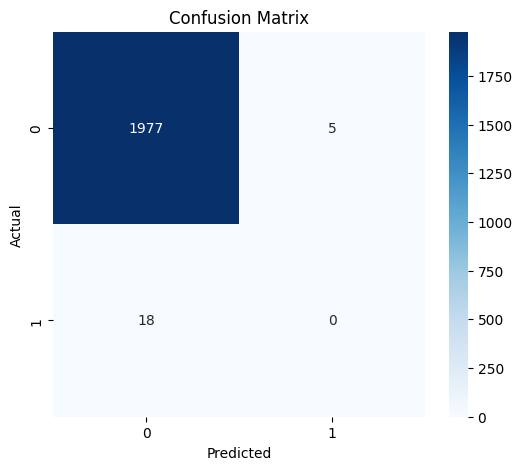

In [55]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [56]:
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

print(len(rf_pred))
print(len(y_test))

2000
2000


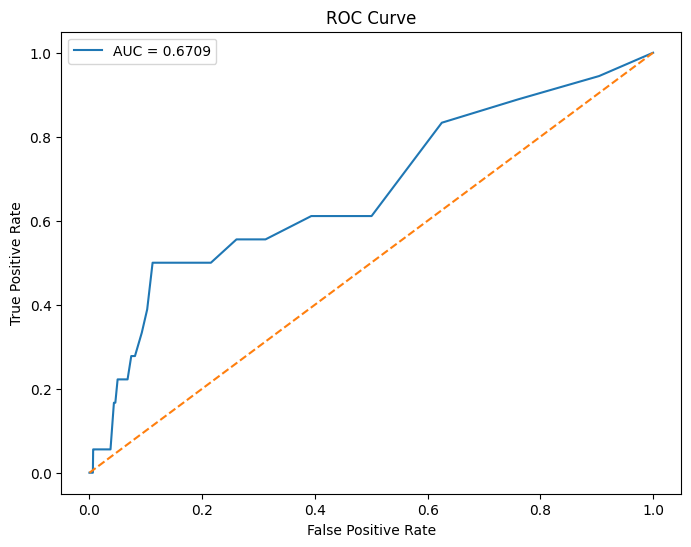

In [57]:
fpr, tpr, _ = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc_score(y_test, y_prob):.4f}"
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [58]:
print("len(y_test) =", len(y_test))
print("len(lr_pred) =", len(lr_pred))
print("len(rf_pred) =", len(rf_pred))

len(y_test) = 2000
len(lr_pred) = 2000
len(rf_pred) = 2000


In [59]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Precision': [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred)
    ],
    'Recall': [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred)
    ],
    'ROC_AUC': [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob)
    ]
})

results

,Model,Precision,Recall,ROC_AUC
0,Logistic Regression,0.011765,0.388889,0.558583
1,Random Forest,0.000000,0.000000,0.670885
